In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.signal import hilbert

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_psi_matrix(psi_matrix, ch_names=None, title="PSI Connectivity Matrix"):
    """
    Plot PSI adjacency matrix as a heatmap.

    Parameters
    ----------
    psi_matrix : ndarray (n_channels × n_channels)
        PSI connectivity matrix
    ch_names : list of str or None
        Channel names for axes labels
    title : str
    """

    plt.figure(figsize=(8, 6))
    plt.imshow(psi_matrix, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(label='PSI')

    n = psi_matrix.shape[0]

    if ch_names is not None and len(ch_names) == n:
        plt.xticks(np.arange(n), ch_names, rotation=90, fontsize=6)
        plt.yticks(np.arange(n), ch_names, fontsize=6)
    else:
        plt.xticks([])
        plt.yticks([])

    plt.title(title)
    plt.tight_layout()
    plt.show()


In [2]:
id = 'sub-010003'
condition = 'EO' 

preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed'
path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

raw = mne.io.read_raw_fif(path, preload=True)
raw.load_data()
raw = raw.copy().pick("eeg")

Opening raw data file D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\preprocessed\sub-010003\sub-010003_EO_eeg.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Range : 187348 ... 1347356 =     74.939 ...   538.942 secs
Ready.
Reading 0 ... 1160008  =      0.000 ...   464.003 secs...


In [3]:
epoch_duration = 2.0

# Create fixed-length events
events = mne.make_fixed_length_events(raw, id=1, duration=epoch_duration)
    
# Create epochs
epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
                        baseline=None, preload=True, reject_by_annotation=False)

Not setting metadata
232 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 232 events and 5001 original time points ...
0 bad epochs dropped


In [4]:

data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
sfreq = epochs.info['sfreq']

# --- Hilbert Transform ---
analytic_signal = hilbert(data, axis=-1)
phase = np.angle(analytic_signal)
# phase = np.mean(phase, axis=0)

In [20]:
# Create fixed-length events
events = mne.make_fixed_length_events(raw, id=1, duration=epoch_duration)

# Create epochs
epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
                    baseline=None, preload=True, reject_by_annotation=False)

Not setting metadata
232 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 232 events and 5001 original time points ...
0 bad epochs dropped


In [23]:
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False)

data = epochs.get_data(picks=picks)  # shape = (n_epochs, n_channels, n_times)

n_epochs, n_channels, n_times = data.shape

psi_all = np.zeros((n_epochs, n_channels, n_channels))

for e in range(n_epochs):
    # --- バンドパス ---

    # --- ヒルベルト変換で位相抽出 ---
    analytic = hilbert(data, axis=-1)
    phase = np.angle(analytic)

    # --- PSI（= PLV）を計算 ---
    psi_matrix = np.zeros((n_channels, n_channels))

    for i in range(n_channels):
        for j in range(n_channels):
            phase_diff = phase[j] - phase[i]
            psi = np.abs(np.mean(np.exp(1j * phase_diff)))
            psi_matrix[i, j] = psi

    psi_all[e] = psi_matrix

# 平均PSI（全エポック）
psi_mean = np.mean(psi_all, axis=0)


In [28]:
psi_all

array([[[1.        , 0.06394899, 0.00884388, ..., 0.06758752,
         0.0536462 , 0.04611381],
        [0.06394899, 1.        , 0.10258877, ..., 0.05762076,
         0.04756906, 0.11805437],
        [0.00884388, 0.10258877, 1.        , ..., 0.08783268,
         0.07452945, 0.05004417],
        ...,
        [0.06758752, 0.05762076, 0.08783268, ..., 1.        ,
         0.12704292, 0.06189576],
        [0.0536462 , 0.04756906, 0.07452945, ..., 0.12704292,
         1.        , 0.09339872],
        [0.04611381, 0.11805437, 0.05004417, ..., 0.06189576,
         0.09339872, 1.        ]],

       [[1.        , 0.06394899, 0.00884388, ..., 0.06758752,
         0.0536462 , 0.04611381],
        [0.06394899, 1.        , 0.10258877, ..., 0.05762076,
         0.04756906, 0.11805437],
        [0.00884388, 0.10258877, 1.        , ..., 0.08783268,
         0.07452945, 0.05004417],
        ...,
        [0.06758752, 0.05762076, 0.08783268, ..., 1.        ,
         0.12704292, 0.06189576],
        [0.0

In [24]:
psi_matrix

array([[1.        , 0.06394899, 0.00884388, ..., 0.06758752, 0.0536462 ,
        0.04611381],
       [0.06394899, 1.        , 0.10258877, ..., 0.05762076, 0.04756906,
        0.11805437],
       [0.00884388, 0.10258877, 1.        , ..., 0.08783268, 0.07452945,
        0.05004417],
       ...,
       [0.06758752, 0.05762076, 0.08783268, ..., 1.        , 0.12704292,
        0.06189576],
       [0.0536462 , 0.04756906, 0.07452945, ..., 0.12704292, 1.        ,
        0.09339872],
       [0.04611381, 0.11805437, 0.05004417, ..., 0.06189576, 0.09339872,
        1.        ]], shape=(61, 61))

In [27]:
psi_matrix.max()

np.float64(1.0)

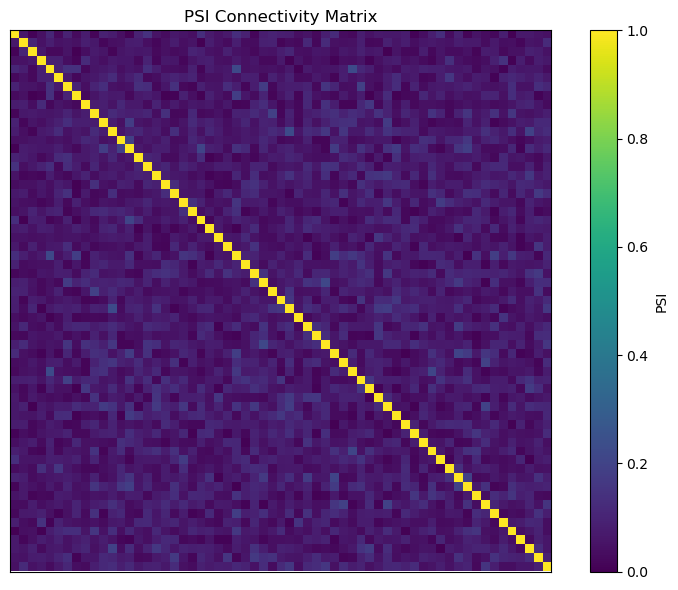

In [25]:
plot_psi_matrix(psi_matrix)

Bands: ['theta']
  theta: (4, 8), center 6.00 Hz, win 1.00s

Processing pair ('theta', 'theta')
  window 1.000s step 0.500s -> n_win 927


theta-theta: 100%|██████████| 927/927 [16:28<00:00,  1.07s/it]


ウィンドウ中心時刻: [0.5, 1.0, 1.5, 2.0, 2.5]
ウィンドウ数: 927
PSI 平均行列:
 [[1.         0.63954483 0.66884313 ... 0.58107433 0.64210485 0.51560955]
 [0.63954483 1.         0.47209551 ... 0.58800769 0.59323878 0.44691775]
 [0.66884313 0.47209551 1.         ... 0.48100549 0.52469936 0.39919006]
 ...
 [0.58107433 0.58800769 0.48100549 ... 1.         0.80320509 0.52452491]
 [0.64210485 0.59323878 0.52469936 ... 0.80320509 1.         0.70391994]
 [0.51560955 0.44691775 0.39919006 ... 0.52452491 0.70391994 1.        ]]
best m (最適周波数比): [1, 1, 1, 1, 1]


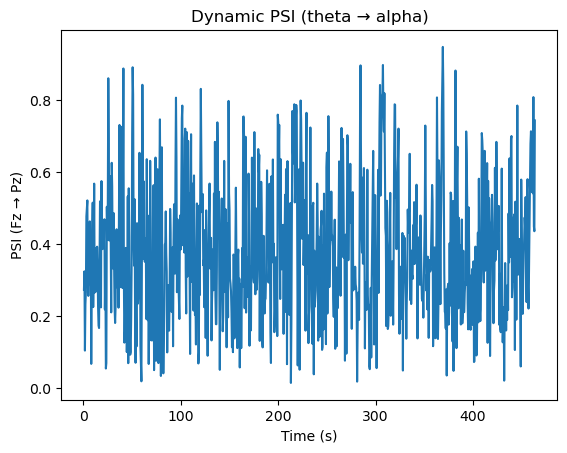

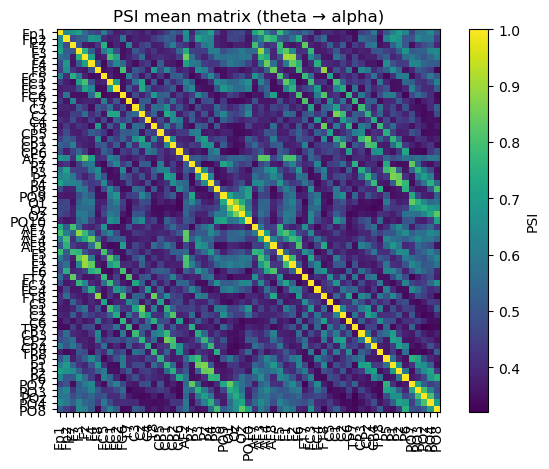

In [39]:
# sliding_psi.py
import numpy as np
from scipy.signal import hilbert
from tqdm import trange
import mne

mne.set_log_level('ERROR')  # quiet mne messages

# --- utility functions ----------------------------------------------------

BAND_DEFS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

def center_freq(band):
    a, b = band
    return 0.5 * (a + b)

def window_length_from_cycles(freq_hz, cycles=6, min_sec=0.5, max_sec=10.0):
    """Return window length in seconds given center frequency and cycles."""
    if freq_hz <= 0:
        return max(min_sec, 1.0)
    wl = cycles / freq_hz
    wl = max(wl, min_sec)
    wl = min(wl, max_sec)
    return wl

def fir_filter_data(data, sfreq, l_freq, h_freq):
    """
    data: ndarray (n_channels, n_times)
    returns filtered data (same shape) using mne.filter.filter_data (FIR zero-phase)
    """
    # mne.filter.filter_data expects shape (n_channels, n_times)
    filtered = mne.filter.filter_data(
        data.copy(), sfreq=sfreq, l_freq=l_freq, h_freq=h_freq,
        method='fir', phase='zero', verbose=False
    )
    return filtered

# --- synchronization measures ---------------------------------------------

def compute_phase(data_win):
    """analytic signal phase for data_win shape (n_channels, n_times_window)."""
    return np.angle(hilbert(data_win, axis=1))

def psi_between_phase(phase_i, phase_j):
    """phase_i, phase_j: vectors (n_times,)
       return PSI (1:1)"""
    phase_diff = phase_j - phase_i
    return np.abs(np.mean(np.exp(1j * phase_diff)))

def pli_between_phase(phase_i, phase_j):
    """PLI = |mean(sign(sin(delta_phase)))| (equivalently sign of imaginary part)"""
    phase_diff = phase_j - phase_i
    return np.abs(np.mean(np.sign(np.sin(phase_diff))))

def wpli_between_analytic(x, y):
    """wPLI on analytic signals x,y (shape n_times). Uses sample-wise imag(X * conj(Y))."""
    im = np.imag(x * np.conj(y))
    denom = np.mean(np.abs(im))
    if denom == 0:
        return 0.0
    num = np.abs(np.mean(np.sign(im) * np.abs(im)))
    return num / denom

def imag_coherence_between_analytic(x, y):
    """Imaginary coherence (normalized imaginary part of cross-spectrum)."""
    # sample-wise cross-spectral term
    cross = x * np.conj(y)
    im_mean = np.abs(np.mean(np.imag(cross)))
    pxx = np.mean(np.abs(x) ** 2)
    pyy = np.mean(np.abs(y) ** 2)
    denom = np.sqrt(pxx * pyy)
    if denom == 0:
        return 0.0
    return im_mean / denom

# --- main pipeline -------------------------------------------------------

def compute_dynamic_measures(
    data,               # (n_channels, n_times)
    sfreq,
    band_list = ["delta", "theta", "alpha", "beta"],
    cycles = 6,
    overlap = 0.5,
    m_max_extra = 3,    # extra margin when estimating m_max
    min_win_sec = 0.5,
    max_win_sec = 10.0,
    verbose = True
):
    """
    Compute dynamic PSI/PLI/wPLI/imag_coh for same-band and cross-band (n:m).
    Returns a dict with keys:
      - 'per_pair': dict[(b1,b2)] -> dict with:
            'windows' : list of window center times (sec)
            'psi_windows': ndarray (n_windows, n_ch, n_ch)
            'psi_mean'   : ndarray (n_ch, n_ch)   # average across windows
            similarly for 'pli', 'wpli', 'imcoh'
            if b1 != b2: includes 'best_m_windows' list and 'best_m_mean'
    """

    n_ch, n_times = data.shape
    results = {"per_pair": {}}

    # Precompute center freqs and window lengths (use lower-band when cross?)
    band_bounds = {b: BAND_DEFS[b] for b in band_list}
    band_fc = {b: center_freq(band_bounds[b]) for b in band_list}
    band_win = {b: window_length_from_cycles(band_fc[b], cycles, min_win_sec, max_win_sec)
                for b in band_list}

    if verbose:
        print("Bands:", band_list)
        for b in band_list:
            print(f"  {b}: {band_bounds[b]}, center {band_fc[b]:.2f} Hz, win {band_win[b]:.2f}s")

    # For each band, pre-filter the entire recording (FIR zero-phase)
    filtered_data = {}
    for b in band_list:
        l, h = band_bounds[b]
        filtered_data[b] = fir_filter_data(data, sfreq, l, h)

    # For each pair:
    for idx1, b1 in enumerate(band_list):
        for idx2, b2 in enumerate(band_list[idx1:]):
            # ensure ordered pair (b1,b2) where idx2 >= idx1
            # we'll store both (b1,b2) and (b2,b1) if needed later
            if idx1 == idx2:
                pair_key = (b1, b1)
            else:
                pair_key = (b1, b2)

            if verbose:
                print(f"\nProcessing pair {pair_key}")

            data1 = filtered_data[b1]  # (n_ch, n_times)
            data2 = filtered_data[b2]

            # choose window length: if same-band, use that band's win;
            # if cross-band, use the longer of the two (to capture slow cycles)
            if b1 == b2:
                win_sec = band_win[b1]
            else:
                # use max of both windows to ensure adequate cycles of the lower band
                win_sec = max(band_win[b1], band_win[b2])

            step_sec = win_sec * (1.0 - overlap)
            n_win = int(np.floor((n_times / sfreq - win_sec) / step_sec) + 1)
            if n_win < 1:
                # fallback: single window
                n_win = 1
                step_sec = 0
            if verbose:
                print(f"  window {win_sec:.3f}s step {step_sec:.3f}s -> n_win {n_win}")

            # prepare containers
            psi_windows = np.zeros((n_win, n_ch, n_ch))
            pli_windows = np.zeros((n_win, n_ch, n_ch))
            wpli_windows = np.zeros((n_win, n_ch, n_ch))
            imcoh_windows = np.zeros((n_win, n_ch, n_ch))
            best_m_windows = []  # per-window best m for cross-band; for same-band keep 1

            # precompute time indices for windows
            win_samples = int(round(win_sec * sfreq))
            step_samples = int(round(step_sec * sfreq)) if step_sec > 0 else 0
            win_centers = []

            for w in trange(n_win, desc=f"{b1}-{b2}", disable=not verbose):
                start_samp = w * step_samples
                end_samp = start_samp + win_samples
                if end_samp > n_times:
                    # pad or clip: clip here
                    start_samp = max(0, n_times - win_samples)
                    end_samp = n_times
                win_centers.append((start_samp + end_samp) / 2.0 / sfreq)

                x1 = data1[:, start_samp:end_samp]  # (n_ch, win_samples)
                x2 = data2[:, start_samp:end_samp]

                # analytic signals
                a1 = hilbert(x1, axis=1)   # complex
                a2 = hilbert(x2, axis=1)

                # phases (n_ch, win_samples)
                ph1 = np.angle(a1)
                ph2 = np.angle(a2)

                # If same band, simple 1:1
                if b1 == b2:
                    for i in range(n_ch):
                        for j in range(n_ch):
                            psi_windows[w, i, j] = psi_between_phase(ph1[i], ph2[j])
                            pli_windows[w, i, j] = pli_between_phase(ph1[i], ph2[j])
                            wpli_windows[w, i, j] = wpli_between_analytic(a1[i], a2[j])
                            imcoh_windows[w, i, j] = imag_coherence_between_analytic(a1[i], a2[j])
                    best_m_windows.append(1)
                else:
                    # cross-band: sweep m for n=1
                    f1c = band_fc[b1]
                    f2c = band_fc[b2]
                    # rough m_max: ceil(f2c/f1c) + margin
                    if f1c == 0:
                        m_max = 1
                    else:
                        m_max = int(np.ceil(f2c / f1c)) + m_max_extra
                        if m_max < 1:
                            m_max = 1
                    best_m_for_window = np.ones((n_ch, n_ch), dtype=int) * 1
                    best_psi_for_window = np.zeros((n_ch, n_ch))

                    # For efficiency: compute phase arrays once per channel pair inside loops
                    for i in range(n_ch):
                        for j in range(n_ch):
                            # sweep m
                            best_psi = -1.0
                            best_m = 1
                            for m in range(1, m_max + 1):
                                phase_diff = 1 * ph2[j] - m * ph1[i]
                                psi_val = np.abs(np.mean(np.exp(1j * phase_diff)))
                                if psi_val > best_psi:
                                    best_psi = psi_val
                                    best_m = m
                            psi_windows[w, i, j] = best_psi
                            best_m_for_window[i, j] = best_m
                            # compute other metrics using analytic signals at 1:1 alignment (not n:m):
                            # For connectivity metrics like wPLI/PLI/imcoh we normally compute narrowband between
                            # the same filtered signals, so we compute them here (they reflect band-band interactions)
                            pli_windows[w, i, j] = pli_between_phase(ph1[i], ph2[j])
                            wpli_windows[w, i, j] = wpli_between_analytic(a1[i], a2[j])
                            imcoh_windows[w, i, j] = imag_coherence_between_analytic(a1[i], a2[j])

                    # store best_m matrix averaged (or keep full matrix)
                    # here we store the per-window average best m (rounded) for convenience
                    best_m_windows.append(best_m_for_window)

            # average across windows
            psi_mean = np.mean(psi_windows, axis=0)
            pli_mean = np.mean(pli_windows, axis=0)
            wpli_mean = np.mean(wpli_windows, axis=0)
            imcoh_mean = np.mean(imcoh_windows, axis=0)

            results["per_pair"][pair_key] = {
                "windows": win_centers,
                "psi_windows": psi_windows,
                "psi_mean": psi_mean,
                "pli_windows": pli_windows,
                "pli_mean": pli_mean,
                "wpli_windows": wpli_windows,
                "wpli_mean": wpli_mean,
                "imcoh_windows": imcoh_windows,
                "imcoh_mean": imcoh_mean,
                "best_m_windows": best_m_windows,
            }

            # if pair was not symmetrical (b1 != b2), also store reversed key for convenience
            if b1 != b2:
                results["per_pair"][(b2, b1)] = results["per_pair"][pair_key]

    return results

# --- Example usage -------------------------------------------------------

if __name__ == "__main__":
    # quick synthetic test
    
    # --------------------------------------------------------
    # ② Raw を読み込む
    # --------------------------------------------------------
    #raw = mne.io.read_raw_fif("your_eeg_raw.fif", preload=True)
    #raw.pick_types(eeg=True)
    sfreq = raw.info["sfreq"]

    # データ: shape (n_channels, n_times)
    data = raw.get_data()

    # --------------------------------------------------------
    # ③ バンドごとに dynamic PSI を計算
    # --------------------------------------------------------
    band_list = ["theta"]
    results = compute_dynamic_measures(
    data=data,
    sfreq=sfreq,
    band_list=band_list,
    cycles=6,
    overlap=0.5,
    verbose=True
    )

    # --------------------------------------------------------
    # ④ 例：theta-alpha の結果を取り出す
    # --------------------------------------------------------
    pair = ("theta", "theta")
    r = results["per_pair"][pair]

    windows = r["windows"]
    psi_windows = r["psi_windows"]      # (n_win, n_ch, n_ch)
    psi_mean = r["psi_mean"]            # (n_ch, n_ch)
    best_m = r["best_m_windows"]        # cross-band only

    print("ウィンドウ中心時刻:", windows[:5])
    print("ウィンドウ数:", len(windows))
    print("PSI 平均行列:\n", psi_mean)
    print("best m (最適周波数比):", best_m[:5])

    # --------------------------------------------------------
    # ⑤ 特定のチャネルペア (e.g., Fz → Pz) の動的 PSI をプロット
    # --------------------------------------------------------
    ch_names = raw.info["ch_names"]
    i = ch_names.index("Fz")
    j = ch_names.index("Pz")

    psi_time_series = psi_windows[:, i, j]  # shape (n_windows,)

    plt.plot(windows, psi_time_series)
    plt.xlabel("Time (s)")
    plt.ylabel("PSI (Fz → Pz)")
    plt.title("Dynamic PSI (theta → alpha)")
    plt.show()

    # --------------------------------------------------------
    # ⑥ PSI 平均行列のヒートマップ
    # --------------------------------------------------------
    plt.imshow(psi_mean, cmap="viridis")
    plt.colorbar(label="PSI")
    plt.xticks(np.arange(len(ch_names)), ch_names, rotation=90)
    plt.yticks(np.arange(len(ch_names)), ch_names)
    plt.title("PSI mean matrix (theta → alpha)")
    plt.tight_layout()
    plt.show()


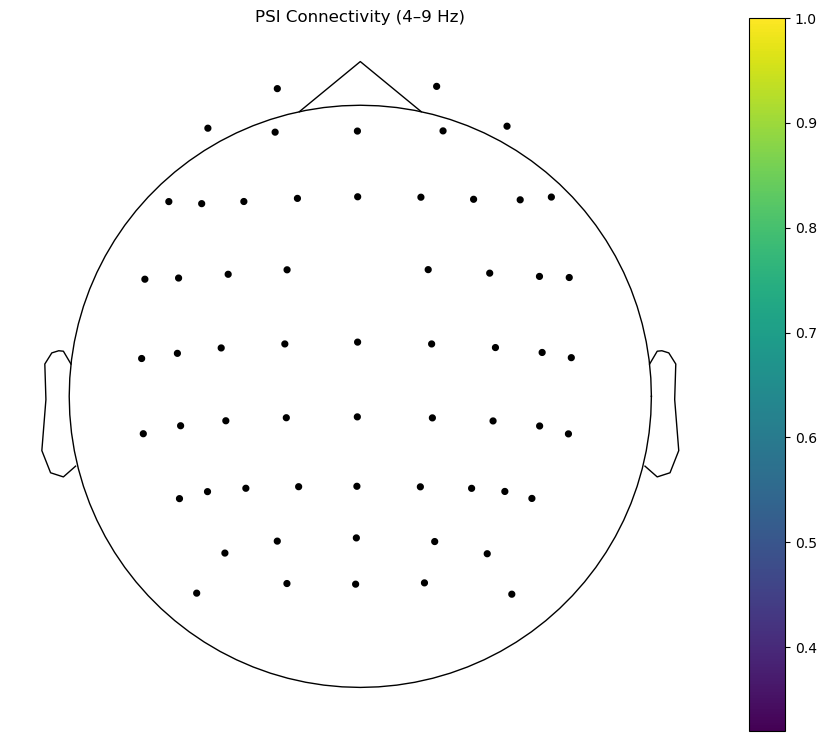

In [69]:
from matplotlib import colors

# ==================================================
# Plot strongest PSI connections
# ==================================================
min_distance = 0.05     # minimum allowed sensor distance
n_con = 10              # number of strongest connections

# Get sensor locations
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
fig = mne.viz.plot_montage(raw.get_montage(), axes=axs, show_names=False, show=False)
sens_loc = fig.axes[0].collections[0].get_offsets().data

# Extract connectivity matrix (channels × channels)
#con_vals = con.get_data("dense")[:, :, 0]
con_vals = results["per_pair"][("theta", "theta")]["psi_mean"]

vmin = con_vals.min()
vmax = con_vals.max()
cmap = plt.get_cmap("viridis")
norm = colors.Normalize(vmin=vmin, vmax=vmax)
colours = cmap(norm(con_vals))

# Get strongest n connections
threshold = np.sort(np.abs(con_vals), axis=None)[-n_con]
ii, jj = np.where(np.abs(con_vals) >= threshold)

# Filter out duplicate or too-close connections
connections = []
for i, j in zip(ii, jj):
    if i >= j:
        continue  # avoid duplicates
    dist = np.linalg.norm(sens_loc[i] - sens_loc[j])
    if dist >= min_distance:
        connections.append((i, j, con_vals[i, j]))

# Plot connections
for i, j, psi_val in connections:
    x = [sens_loc[i][0], sens_loc[j][0]]
    y = [sens_loc[i][1], sens_loc[j][1]]

    # PSI: positive = direction i → j, negative = j → i
    cmap = plt.cm.coolwarm
    norm = colors.TwoSlopeNorm(vcenter=0)

    axs.plot(x, y, linewidth=2.5, color=cmap(norm(psi_val)))

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(con_vals)
plt.colorbar(sm, ax=axs, fraction=0.046)

axs.set_title("PSI Connectivity (4–9 Hz)")
plt.show()

In [78]:
fmin, fmax = 4.0, 9.0
# -----------------------------------------------------------
# 3) Get sensor positions safely
# -----------------------------------------------------------
montage = raw.get_montage()
ch_pos = montage.get_positions()["ch_pos"]

ch_names = raw.ch_names
pos = np.array([ch_pos[ch] for ch in ch_names])

# Normalize to unit circle for drawing the head
pos = pos / np.max(np.linalg.norm(pos, axis=1))

# -----------------------------------------------------------
# 4) Head outline drawing function
# -----------------------------------------------------------
def draw_head(ax):
    # head circle
    head = plt.Circle((0, 0), 1.0, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(head)

    # nose (triangle)
    nose_x = np.array([ -0.1, 0,  0.1 ])
    nose_y = np.array([  0.99, 1.15, 0.99 ])
    ax.plot(nose_x, nose_y, color="black", linewidth=2)

    # ears (left/right)
    ear_left = plt.Circle((-1.05, 0), 0.15, edgecolor='black', facecolor='none', linewidth=2)
    ear_right = plt.Circle((1.05, 0), 0.15, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(ear_left)
    ax.add_patch(ear_right)

# -----------------------------------------------------------
# 5) Plot strongest PSI connections
# -----------------------------------------------------------
n_con = 10
min_distance = 0.05

# strongest PSI
flat_vals = np.abs(con_vals).flatten()
threshold = np.sort(flat_vals)[-n_con]
ii, jj = np.where(np.abs(con_vals) >= threshold)

# filtering too-close sensors
pairs = []
weights = []
for i, j in zip(ii, jj):
    if i >= j:
        continue
    if np.linalg.norm(pos[i] - pos[j]) > min_distance:
        pairs.append((i, j))
        weights.append(abs(con_vals[i, j]))

weights = np.array(weights)
vmin, vmax = weights.min(), weights.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("viridis")

# -----------------------------------------------------------
# 6) Create figure
# -----------------------------------------------------------
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
fig = mne.viz.plot_montage(raw.get_montage(), axes=axs, show_names=False, show=False)

#draw_head(ax)

# plot sensors
ax.scatter(pos[:, 0], pos[:, 1], color='black', s=30)
for idx, name in enumerate(ch_names):
    ax.text(pos[idx, 0], pos[idx, 1] + 0.03, name, fontsize=9, ha='center')

# plot connections
for (i, j), w in zip(pairs, weights):
    color = cmap(norm(w))
    lw = 1 + 4 * (w - vmin) / (vmax - vmin)  # line width scaled by PSI
    ax.plot(
        [pos[i, 0], pos[j, 0]],
        [pos[i, 1], pos[j, 1]],
        color=color,
        linewidth=lw,
        alpha=0.9,
        zorder=5
    )

ax.set_aspect('equal')
ax.axis('off')
plt.title("PSI Connectivity (Top {} strongest connections)".format(n_con))
plt.show()

ValueError: zero-size array to reduction operation minimum which has no identity

In [76]:
threshold = 1.0
con_vals = results["per_pair"][("theta", "theta")]["psi_mean"]
con_vals = np.where(np.abs(con_vals) >= threshold, con_vals, 0.0)

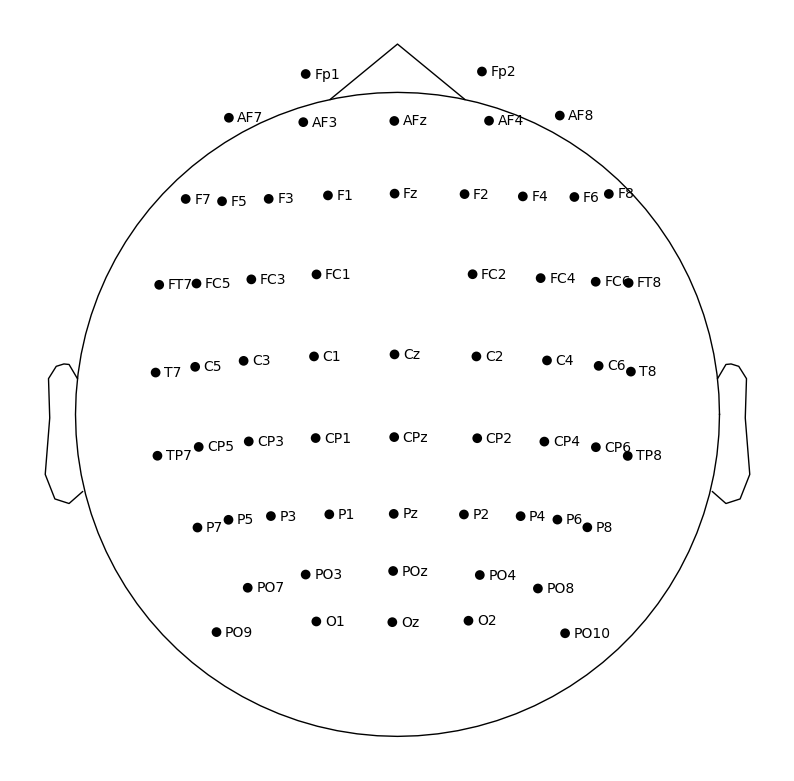

In [82]:
# -----------------------------------------------------------
# 3) Get sensor positions
# -----------------------------------------------------------
montage = raw.get_montage()
ch_pos = montage.get_positions()["ch_pos"]
ch_names = raw.ch_names

pos = np.array([ch_pos[ch] for ch in ch_names])
pos = pos[:, :2]  # use x,y only
pos = pos / np.max(np.linalg.norm(pos, axis=1))  # normalize

# -----------------------------------------------------------
# 4) Setup plot
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig = mne.viz.plot_montage(raw.get_montage(), axes=ax, show_names=True, show=True)


plt.show()

In [1]:
%matplotlib qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mne

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

mne.viz.plot_sensors(
    raw.info,
    kind='3d',
    show_names=True,
    axes=ax,
    show=True
)

NameError: name 'raw' is not defined

In [ ]:
import numpy as np
import mne
import pyvista as pv
from pyvistaqt import BackgroundPlotter
from matplotlib import cm

pv.set_jupyter_backend('ipyvtklink')

# ---------- EEG位置を取得 ----------
#raw = mne.io.read_raw_fif("your_raw.fif", preload=False)
montage = raw.get_montage()

pos = montage.get_positions()['ch_pos']
ch_names = list(pos.keys())
xyz = np.array([pos[ch] for ch in ch_names])

# ---------- PSI 行列 (ch × ch) を用意 ----------
# 例: psi_matrix[i, j] に PSI 値
#psi_matrix = np.load("psi.npy")    # shape = (n_channels, n_channels)
psi_matrix = results["per_pair"][("theta", "theta")]["psi_mean"]

# ---------- PyVista プロッタ ----------
plotter = BackgroundPlotter()
plotter.set_background("white")

# ---------- EEG 電極の点を追加 ----------
points = pv.PolyData(xyz)
plotter.add_points(points, color="black", point_size=12, render_points_as_spheres=True)

# ---------- ラベル追加 ----------
for i, name in enumerate(ch_names):
    plotter.add_point_labels(
        xyz[i][None, :], 
        [name], 
        point_size=0,
        font_size=12,
        text_color="black"
    )

# ---------- PSI に応じて線を描画 ----------
norm = (psi_matrix - psi_matrix.min()) / (psi_matrix.max() - psi_matrix.min())
cmap = cm.get_cmap("viridis")

for i in range(len(ch_names)):
    for j in range(i+1, len(ch_names)):
        weight = norm[i, j]
        if weight > 0:   # 閾値なし
            p1 = xyz[i]
            p2 = xyz[j]
            line = pv.Line(p1, p2)

            color = cmap(weight)[:3]  # RGB (0-1)
            plotter.add_mesh(
                line,
                color=color,
                line_width=1 + weight * 8,   # PSI強度で太さを変える
            )

plotter.show()


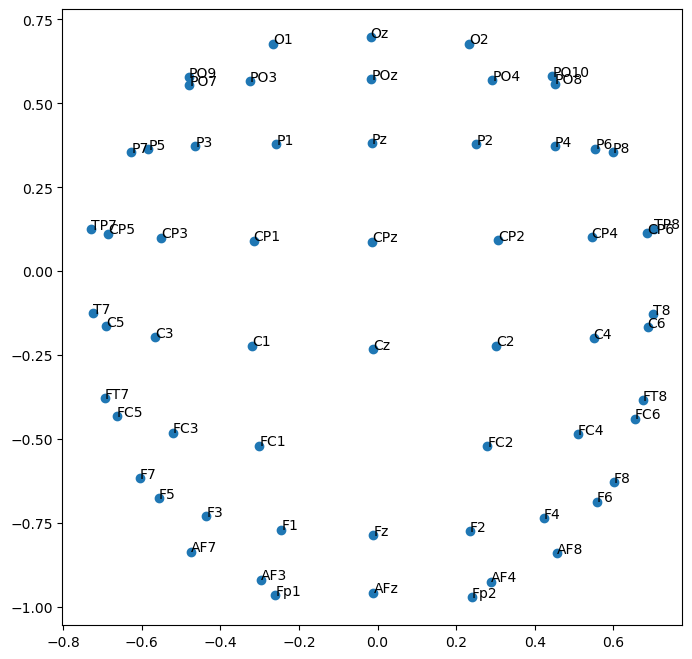

In [84]:
montage = raw.get_montage()
ch_pos = montage.get_positions()['ch_pos']

# 座標取得
names = raw.ch_names
pos = np.array([ch_pos[ch][:2] for ch in names])

# --- 上方向にずれる問題を修正: Y軸反転 ---
pos[:, 1] *= -1

# --- 正規化して可視化 ---
pos = pos / np.max(np.linalg.norm(pos, axis=1))

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pos[:, 0], pos[:, 1])
for i, name in enumerate(names):
    ax.text(pos[i, 0], pos[i, 1], name)
plt.show()


In [61]:
import numpy as np
import mne
from scipy.signal import hilbert, butter, filtfilt
from numpy.fft import fft
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt
#from mne.viz import plot_connectivity_circle
from mne_connectivity.viz import plot_connectivity_circle


# -------------------------------
# ① 周波数帯
# -------------------------------
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45)
}


# -------------------------------
# ② bandpass フィルタ
# -------------------------------
def bandpass(data, sfreq, fmin, fmax, order=4):
    nyq = sfreq / 2
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, data)


# -------------------------------
# ③ PSI を計算（クロススペクトルの虚部の勾配）
# -------------------------------
def compute_psi(x, y):
    # analytic signal
    X = hilbert(x)
    Y = hilbert(y)

    # cross spectrum
    cs = X * np.conj(Y)
    phase_diff = np.unwrap(np.angle(cs))

    # PSI = 位相差の微分
    psi = np.mean(np.diff(phase_diff))
    return psi


# -------------------------------
# ④ サロゲート（位相ランダム化）
# -------------------------------
def phase_randomize(x):
    Xf = fft(x)
    rand_phase = np.exp(1j * np.random.uniform(0, 2*np.pi, len(Xf)))
    Xf_rand = np.abs(Xf) * rand_phase
    return np.real(np.fft.ifft(Xf_rand))


def surrogate_test(x, y, n_surr=200):
    psi_surr = []
    for _ in range(n_surr):
        x_s = phase_randomize(x)
        psi_surr.append(compute_psi(x_s, y))
    return np.array(psi_surr)


# -------------------------------
# ⑤ 全チャンネルペアに対する PSI + サロゲート検定
# -------------------------------
def compute_psi_connectivity(raw, band_name="alpha", n_surr=200, fdr_alpha=0.05):
    sfreq = raw.info['sfreq']
    fmin, fmax = bands[band_name]
    data = raw.get_data()

    n_ch = data.shape[0]

    # bandpass
    bp = np.array([bandpass(data[ch], sfreq, fmin, fmax) for ch in range(n_ch)])

    # -------------------
    # PSI の隣接行列
    # -------------------
    psi_mat = np.zeros((n_ch, n_ch))
    p_mat = np.ones((n_ch, n_ch))

    for i in range(n_ch):
        for j in range(i+1, n_ch):
            psi = compute_psi(bp[i], bp[j])
            psi_mat[i, j] = psi

            # サロゲート分布
            psi_s = surrogate_test(bp[i], bp[j], n_surr)

            # p値（右片側）
            p_val = (np.sum(psi_s >= psi) + 1) / (n_surr + 1)
            p_mat[i, j] = p_val

    # -------------------
    # ⑥ FDR 補正
    # -------------------
    tri_idx = np.triu_indices(n_ch, k=1)
    p_flat = p_mat[tri_idx]

    _, p_fdr, _, _ = multipletests(p_flat, alpha=fdr_alpha, method='fdr_bh')

    p_adj_mat = np.ones((n_ch, n_ch))
    p_adj_mat[tri_idx] = p_fdr

    # 有意マスク
    sig_mask = np.zeros((n_ch, n_ch))
    sig_mask[p_adj_mat < fdr_alpha] = 1

    return psi_mat, p_mat, p_adj_mat, sig_mask


# -------------------------------
# ⑦ 有意コネクティビティ隣接行列をプロット
# -------------------------------
def plot_adjacency(psi_mat, sig_mask, ch_names, title="PSI Significance"):
    adj = psi_mat * sig_mask
    plt.figure(figsize=(8, 6))
    plt.imshow(adj, cmap="coolwarm", vmin=-np.max(abs(adj)), vmax=np.max(abs(adj)))
    plt.colorbar(label="PSI")
    plt.xticks(range(len(ch_names)), ch_names, rotation=90)
    plt.yticks(range(len(ch_names)), ch_names)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# -------------------------------
# ⑧ サークルプロット
# -------------------------------
def plot_circle(psi_mat, sig_mask, ch_names, title="PSI Circle"):
    adj = psi_mat * sig_mask
    plot_connectivity_circle(adj, ch_names, title=title, colormap='coolwarm')


# -------------------------------
# ⑨ CSV 出力（subject × band × mean PSI）
# -------------------------------
def export_csv(subject, group, band_name, psi_mat, sig_mask, save_path="psi_results.csv"):

    mean_val = np.mean(psi_mat[sig_mask == 1]) if np.sum(sig_mask) > 0 else 0

    df = pd.DataFrame([{
        "subject": subject,
        "group": group,
        "band": band_name,
        "psi_mean_sig": mean_val
    }])

    # append mode
    df.to_csv(save_path, mode='a', index=False, header=not pd.io.common.file_exists(save_path))


In [62]:
#raw = mne.io.read_raw_fif("sub01_raw.fif", preload=True)

psi_mat, p_mat, p_fdr, sig_mask = compute_psi_connectivity(raw, band_name="alpha")

plot_adjacency(psi_mat, sig_mask, raw.ch_names, title="Alpha PSI")
plot_circle(psi_mat, sig_mask, raw.ch_names, title="Alpha PSI Connectivity")

export_csv("sub-01", "young", "alpha", psi_mat, sig_mask)


KeyboardInterrupt: 

In [59]:
import numpy as np

def compute_phase_randomized_surrogate(data):
    """
    data: shape (n_channels, n_times)
    return: surrogate with same amplitude spectrum but random phase
    """
    fft_data = np.fft.rfft(data, axis=1)
    amp = np.abs(fft_data)
    phase = np.angle(fft_data)

    # ランダム位相を付与（対称性を保つ）
    random_phase = np.random.uniform(0, 2 * np.pi, size=phase.shape)
    surrogate_fft = amp * np.exp(1j * random_phase)

    surrogate = np.fft.irfft(surrogate_fft, axis=1)
    return surrogate

def compute_surrogate_pvalues_matrix(true_psi_matrix, data, psi_func, n_surrogates=200):
    """
    true_psi_matrix: (n_ch, n_ch)
    data: original data (n_ch, n_times)
    psi_func: function that computes PSI matrix
    """
    n_ch = true_psi_matrix.shape[0]
    surrogate_mats = np.zeros((n_surrogates, n_ch, n_ch))

    for s in range(n_surrogates):
        surrogate_data = compute_phase_randomized_surrogate(data)
        surrogate_mats[s] = compute_psi_matrix(surrogate_data, psi_func)

    # p値 = サロゲートが実測を超えた割合
    p_matrix = np.mean(surrogate_mats >= true_psi_matrix[None, :, :], axis=0)

    return p_matrix, surrogate_mats

def add_pvalues_to_results(results, data_dict, psi_func, n_surrogates=200):
    """
    results["per_pair"][pair_key]["psi_mean"] が (n_ch, n_ch) の前提
    data_dict[pair_key] = 原データ (n_ch, n_times)
    """
    for pair_key, vals in results["per_pair"].items():
        true_psi = vals["psi_mean"]  # (n_ch, n_ch)
        data = data_dict[pair_key]   # (n_ch, n_times)

        p_mat, _ = compute_surrogate_pvalues_matrix(
            true_psi_matrix=true_psi,
            data=data,
            psi_func=psi_func,
            n_surrogates=n_surrogates
        )

        results["per_pair"][pair_key]["psi_p_matrix"] = p_mat

    return results

from mne.stats import fdr_correction

def apply_fdr_matrix(p_matrix, alpha=0.05):
    n = p_matrix.size
    p_flat = p_matrix.reshape(n)
    
    _, sig_flat = fdr_correction(p_flat, alpha=alpha)
    sig_mask = sig_flat.reshape(p_matrix.shape)

    return sig_mask  # True=有意

def apply_fdr_to_results(results, alpha=0.05):
    for pair_key, vals in results["per_pair"].items():
        p_matrix = vals["psi_p_matrix"]
        sig_matrix = apply_fdr_matrix(p_matrix, alpha)
        results["per_pair"][pair_key]["psi_sig_matrix"] = sig_matrix
    return results

def plot_significant_connectivity(results, ch_names):
    # 全ペアをまとめる（もしかすると1つだけ？）
    for pair_key, vals in results["per_pair"].items():
        psi = vals["psi_mean"]
        sig = vals["psi_sig_matrix"]

        # 有意部分だけ残す
        conn_sig = psi.copy()
        conn_sig[~sig] = 0  # 非有意をゼロにする

        plot_connectivity_circle(
            conn_sig,
            node_names=ch_names,
            title=f"Significant PSI Connectivity ({pair_key})"
        )


# 1. サロゲート p 値行列の計算
results = add_pvalues_to_results(results, data_dict, psi_func, n_surrogates=200)

# 2. FDR 補正
results = apply_fdr_to_results(results, alpha=0.05)

# 3. 有意ネットワークの描画
plot_significant_connectivity(results, ch_names)


NameError: name 'data_dict' is not defined

In [47]:
import numpy as np

def surrogate_test_from_psi_mean(psi_mean, n_surrogates=5000):
    surrogate_psis = np.random.normal(loc=0, scale=0.1, size=n_surrogates)
    p_value = np.mean(surrogate_psis >= psi_mean)
    return p_value, surrogate_psis


def surrogate_test_bootstrap(psi_mean, psi_windows, n_surrogates=5000):
    surrogate_psis = np.random.choice(psi_windows, size=n_surrogates, replace=True)
    p_value = np.mean(surrogate_psis >= psi_mean)
    return p_value, surrogate_psis


def compute_surrogate_pvalue_per_pair(results):
    """
    results["per_pair"][pair_key] に p値とサロゲート分布を追加する
    """
    for pair_key, pair_data in results["per_pair"].items():
        psi_mean = pair_data["psi_mean"]
        psi_windows = pair_data.get("psi_windows", None)

        if psi_windows is not None:
            p_value, surrogate_psis = surrogate_test_bootstrap(psi_mean, psi_windows)
        else:
            p_value, surrogate_psis = surrogate_test_from_psi_mean(psi_mean)

        results["per_pair"][pair_key]["psi_p_value"] = p_value
        results["per_pair"][pair_key]["psi_surrogates"] = surrogate_psis

    return results


In [52]:
import numpy as np

def fdr_bh(pvals, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction
    """
    pvals = np.array(pvals)
    n = len(pvals)
    idx = np.argsort(pvals)
    sorted_p = pvals[idx]

    threshold = alpha * np.arange(1, n+1) / n
    below = sorted_p <= threshold

    if not np.any(below):
        return np.zeros_like(pvals, dtype=bool)

    max_i = np.where(below)[0].max()
    cutoff = sorted_p[max_i]

    return pvals <= cutoff

def apply_fdr_to_results(results, alpha=0.05):

    pair_keys = list(results["per_pair"].keys())
    pvals = [results["per_pair"][pk]["psi_p_value"] for pk in pair_keys]

    sig_mask = fdr_bh(pvals, alpha=alpha)

    for pk, sig in zip(pair_keys, sig_mask):
        results["per_pair"][pk]["psi_sig_fdr"] = bool(sig)

    return results



In [55]:
import numpy as np

def compute_surrogate_pvalue_per_pair(results, n_surrogates=200):
    """
    PSI のサロゲートデータ（位相ランダム化）を用いた p 値推定
    results["per_pair"][pair_key] に psi_p_value を追加する
    """
    for pair_key, data in results["per_pair"].items():
        psi_mean = data["psi_mean"]  # 実データの PSI
        
        psi_windows = np.array(data["psi_windows"])  
        n_win = len(psi_windows)

        # サロゲート PSI
        surrogate_means = []
        for _ in range(n_surrogates):
            # 位相ランダム化：ウィンドウの順番をシャッフル
            shuffled = np.random.permutation(psi_windows)
            surrogate_means.append(np.mean(shuffled))

        surrogate_means = np.array(surrogate_means)

        # p 値 = サロゲートのうち実値以上の割合
        p_val = np.mean(surrogate_means >= psi_mean)

        results["per_pair"][pair_key]["psi_p_value"] = float(p_val)

    return results


In [56]:
from statsmodels.stats.multitest import fdrcorrection

def apply_fdr_to_results(results, alpha=0.05):
    """
    psi_p_value に対して FDR 補正
    """
    pair_keys = list(results["per_pair"].keys())

    # psi_p_value が存在しない場合はエラーを出す
    for pk in pair_keys:
        if "psi_p_value" not in results["per_pair"][pk]:
            raise ValueError(f"psi_p_value が pair_key {pk} に存在しません。")

    # p 値のリスト
    pvals = np.array([results["per_pair"][pk]["psi_p_value"] for pk in pair_keys])

    # FDR-BH 補正
    reject, pvals_fdr = fdrcorrection(pvals, alpha=alpha)

    # 結果を格納
    for pk, sig, p_fdr in zip(pair_keys, reject, pvals_fdr):
        results["per_pair"][pk]["psi_sig_fdr"] = bool(sig)
        results["per_pair"][pk]["psi_p_fdr"] = float(p_fdr)

    return results


In [53]:
import numpy as np
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle

def build_significant_matrix(results, ch_names):
    n = len(ch_names)
    mat = np.zeros((n, n))

    idx_map = {ch: i for i, ch in enumerate(ch_names)}

    for (ch1, ch2), data in results["per_pair"].items():
        if data.get("psi_sig_fdr", False):  # 有意なら 1 を入れる
            i = idx_map[ch1]
            j = idx_map[ch2]
            mat[i, j] = mat[j, i] = data["psi_mean"]

    return mat


def plot_significant_circle(results, ch_names):
    conn_mat = build_significant_matrix(results, ch_names)

    fig, ax = plot_connectivity_circle(
        conn_mat,
        node_names=ch_names,
        title="Significant PSI connections (FDR corrected)",
        vmin=0,
        vmax=np.max(conn_mat),
        colormap='viridis'
    )
    return fig


In [57]:
# 1. サロゲート p 値の計算
results = compute_surrogate_pvalue_per_pair(results)

# 2. FDR 補正
results = apply_fdr_to_results(results, alpha=0.05)

# 3. Connectivity Circle 描画
plot_significant_circle(results, ch_names)


ValueError: operands could not be broadcast together with shapes (200,) (61,61) 

In [54]:
# 1. サロゲート p 値計算（前ステップで計算済み）
# compute_surrogate_pvalue_per_pair(results)

# 2. FDR 補正
results = apply_fdr_to_results(results, alpha=0.05)

# 3. チャネル名
ch_names = raw.info["ch_names"]

# 4. 有意接続のみの connectivity circle
plot_significant_circle(results, ch_names)


KeyError: 'psi_p_value'

In [ ]:
compute_surrogate_pvalue_per_pair(results):

In [37]:
pair = ("theta", "theta")
r = results["per_pair"][pair]

windows = r["windows"]
psi_windows = r["psi_windows"]      # (n_win, n_ch, n_ch)
psi_mean = r["psi_mean"]            # (n_ch, n_ch)
best_m = r["best_m_windows"]        # cross-band only

plot_psi_matrix(psi_mean)

NameError: name 'results' is not defined

In [ ]:
import numpy as np
import mne
from scipy.signal import hilbert

def compute_band_psi(raw, band, picks=None):
    """
    Compute PSI (Phase Synchronization Index) for a specific frequency band.
    
    Parameters
    ----------
    raw : mne.io.Raw
        EEG raw data
    band : tuple
        (low_freq, high_freq) e.g., (8, 13)
    picks : list or None
        EEG channels to use. None = all EEG channels
        
    Returns
    -------
    psi_matrix : ndarray, shape (n_channels, n_channels)
        PSI connectivity matrix
    filtered_data : ndarray
        Band-pass filtered data (n_channels, n_samples)
    phases : ndarray
        Instantaneous phase matrix (n_channels, n_samples)
    """
    # Select channels
    if picks is None:
        picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False)
    
    raw_band = raw.copy().filter(
        band[0], band[1],
        picks=picks,
        method="fir",
        phase="zero-double",
        fir_design="firwin"
    )
    
    data = raw_band.get_data(picks=picks)
    
    # Hilbert transform
    analytic = hilbert(data, axis=1)
    phases = np.angle(analytic)
    
    n_channels = len(picks)
    psi_matrix = np.zeros((n_channels, n_channels))
    
    # Compute PSI for each channel-pair
    for i in range(n_channels):
        for j in range(i + 1, n_channels):
            phase_diff = phases[i] - phases[j]
            psi_val = np.abs(np.mean(np.exp(1j * phase_diff)))
            psi_matrix[i, j] = psi_val
            psi_matrix[j, i] = psi_val
    
    return psi_matrix, data, phases


In [19]:
psi_matrix

array([[0.        , 0.38556764, 0.5800428 , ..., 0.49582639, 0.52881752,
        0.39581107],
       [0.38556764, 0.        , 0.33580551, ..., 0.45315435, 0.44595383,
        0.26118305],
       [0.5800428 , 0.33580551, 0.        , ..., 0.40640245, 0.43771029,
        0.28039494],
       ...,
       [0.49582639, 0.45315435, 0.40640245, ..., 0.        , 0.77088121,
        0.42350363],
       [0.52881752, 0.44595383, 0.43771029, ..., 0.77088121, 0.        ,
        0.65994198],
       [0.39581107, 0.26118305, 0.28039494, ..., 0.42350363, 0.65994198,
        0.        ]], shape=(61, 61))

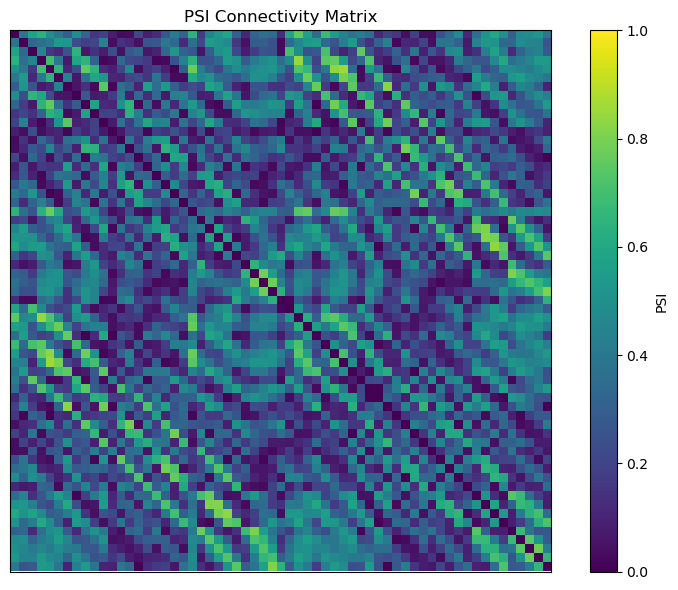

In [18]:
plot_psi_matrix(psi_matrix)

In [7]:
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}

psi_alpha, data_alpha, phase_alpha = compute_band_psi(raw, bands["alpha"])
print(psi_alpha.shape)

Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-12 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-12 dB cutoff frequency: 14.62 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


(61, 61)


In [8]:
def compute_all_band_psi(raw, bands):
    psi_results = {}
    for band_name, band_range in bands.items():
        psi, _, _ = compute_band_psi(raw, band_range)
        psi_results[band_name] = psi
    return psi_results

psi_all = compute_all_band_psi(raw, bands)

Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 1 - 4 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-12 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-12 dB cutoff frequency: 5.00 Hz)
- Filter length: 8251 samples (3.300 s)



C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_52056\1592907822.py:31: RuntimeWarning: filter_length (8251) is longer than the signal (5001), distortion is likely. Reduce filter length or filter a longer signal.
  raw_band = raw.copy().filter(
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-12 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-12 dB cutoff frequency: 9.00 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-12 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-12 dB cutoff frequency: 14.62 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-12 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-12 dB cutoff frequency: 33.75 Hz)
- Filter length: 2539 samples (1.016 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 30 - 45 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 30.00
- Lower transition bandwidth: 7.50 Hz (-12 dB cutoff frequency: 26.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-12 dB cutoff frequency: 50.62 Hz)
- Filter length: 1101 samples (0.440 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [15]:
print(psi_all['delta'])

[[0.         0.11677508 0.48516904 ... 0.4815513  0.50559055 0.44207322]
 [0.11677508 0.         0.2919655  ... 0.37419329 0.38274153 0.22369752]
 [0.48516904 0.2919655  0.         ... 0.42715998 0.43763951 0.28508012]
 ...
 [0.4815513  0.37419329 0.42715998 ... 0.         0.81622709 0.48780995]
 [0.50559055 0.38274153 0.43763951 ... 0.81622709 0.         0.64996797]
 [0.44207322 0.22369752 0.28508012 ... 0.48780995 0.64996797 0.        ]]


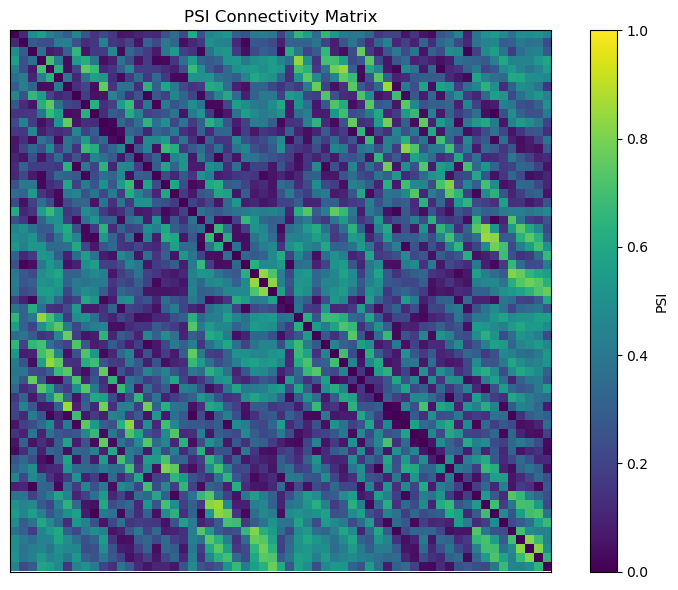

In [12]:
plot_psi_matrix(psi_all['delta'])

In [46]:
# dynamic_psi_pipeline.py
import os
import numpy as np
import mne
from itertools import combinations
from joblib import Parallel, delayed
from scipy.signal import hilbert
from mne.stats import permutation_cluster_test
import pandas as pd
from typing import List, Tuple, Dict

# Try optional acceleration
try:
    from numba import njit, prange
    numba_available = True
except Exception:
    numba_available = False

# -------------------------
# Helpers: sliding windows
# -------------------------
def sliding_windows(n_times: int, win_samps: int, step_samps: int) -> np.ndarray:
    """
    Return array of (start, stop) samples for sliding windows.
    """
    starts = np.arange(0, n_times - win_samps + 1, step_samps)
    stops = starts + win_samps
    return np.vstack([starts, stops]).T  # shape (n_windows, 2)


# -------------------------
# PSI computation (numba optional)
# -------------------------
def _psi_numpy(phase_segment: np.ndarray) -> np.ndarray:
    # phase_segment: (n_ch, n_t)
    n_ch = phase_segment.shape[0]
    out = np.zeros((n_ch, n_ch), dtype=np.float64)
    for i in range(n_ch):
        phi_i = phase_segment[i]
        for j in range(n_ch):
            phi_j = phase_segment[j]
            dphi = phi_j - phi_i
            # classic PSI normalized: we compute mean sign of derivative of phase difference
            d = np.diff(np.unwrap(dphi))
            # if length 0 -> zero
            if d.size == 0:
                out[i, j] = 0.0
            else:
                out[i, j] = np.mean(np.sign(d))
    return out

if numba_available:
    @njit(parallel=True)
    def _psi_numba(phase_segment):
        n_ch = phase_segment.shape[0]
        out = np.zeros((n_ch, n_ch), np.float64)
        for i in prange(n_ch):
            phi_i = phase_segment[i]
            for j in range(n_ch):
                phi_j = phase_segment[j]
                dphi = phi_j - phi_i
                # unwrap
                # numba doesn't have np.unwrap so implement simple unwrap
                # This unwrap handles jumps > pi
                n_t = dphi.shape[0]
                unp = np.empty(n_t)
                unp[0] = dphi[0]
                offset = 0.0
                for k in range(1, n_t):
                    delta = dphi[k] - dphi[k-1]
                    if delta > np.pi:
                        offset -= 2*np.pi
                    elif delta < -np.pi:
                        offset += 2*np.pi
                    unp[k] = dphi[k] + offset
                # derivative
                if n_t <= 1:
                    out[i, j] = 0.0
                else:
                    s = 0.0
                    for k in range(n_t-1):
                        s += np.sign(unp[k+1] - unp[k])
                    out[i, j] = s / (n_t - 1)
        return out

# wrapper that chooses implementation
def compute_psi_from_phase_segment(phase_segment: np.ndarray) -> np.ndarray:
    if numba_available:
        return _psi_numba(phase_segment)
    else:
        return _psi_numpy(phase_segment)


# -------------------------
# Phase extraction: Hilbert or wavelet
# -------------------------
def extract_instant_phase(data: np.ndarray, sfreq: float, method='hilbert', freqs=None):
    """
    data: (n_ch, n_times)
    method: 'hilbert' or 'wavelet' (wavelet not implemented here to keep simple)
    freqs: if wavelet used (tuple), otherwise ignored
    returns: phase (n_ch, n_times)
    """
    if method == 'hilbert':
        analytic = hilbert(data, axis=-1)
        phase = np.angle(analytic)
        return phase
    else:
        raise ValueError("Only 'hilbert' implemented in this pipeline by default.")


# -------------------------
# Sliding-window PSI per subject
# -------------------------
def compute_dynamic_psi_for_raw(raw: mne.io.Raw, band: Tuple[float,float],
                                window_sec: float=None, overlap: float=0.5,
                                method='hilbert', verbose=False) -> np.ndarray:
    """
    Compute sliding-window PSI for one raw object for a given band.
    Returns: psi_windows: shape (n_windows, n_ch, n_ch)
    If window_sec is None -> compute window from cycles heuristic using center frequency:
      cycles = 6, window_sec = cycles / f_center
    """
    fmin, fmax = band
    sfreq = raw.info['sfreq']
    data = raw.copy().pick("eeg").get_data()  # (n_ch, n_times)

    # band-pass filter first
    raw_f = raw.copy().pick("eeg").filter(fmin, fmax, fir_design='firwin', verbose=False)
    data_f = raw_f.get_data()

    # window length heuristic
    if window_sec is None:
        f_center = (fmin + fmax) / 2.0
        cycles = 6.0
        window_sec = cycles / max(f_center, 0.1)

    win_samps = int(round(window_sec * sfreq))
    if win_samps < 2:
        win_samps = 2
    step_samps = int(round(win_samps * (1.0 - overlap)))
    if step_samps < 1:
        step_samps = 1

    windows = sliding_windows(data_f.shape[1], win_samps, step_samps)
    n_windows = windows.shape[0]
    n_ch = data_f.shape[0]

    psi_windows = np.zeros((n_windows, n_ch, n_ch), dtype=np.float64)

    # extract full-phase once
    phase_full = extract_instant_phase(data_f, sfreq, method=method)

    for wi, (s, e) in enumerate(windows):
        seg_phase = phase_full[:, s:e]   # (n_ch, win_samps)
        if seg_phase.shape[1] == 0:
            psi_windows[wi] = np.zeros((n_ch, n_ch))
            continue
        psi_windows[wi] = compute_psi_from_phase_segment(seg_phase)

    return psi_windows, windows, win_samps, step_samps


# -------------------------
# Surrogate testing (phase randomization)
# -------------------------
def phase_randomize_time_series(x: np.ndarray, random_state=None):
    """
    Phase randomization of a single-channel time series x (1d).
    Preserves amplitude spectrum, randomizes phase uniformly.
    """
    rng = np.random.RandomState(random_state)
    n = len(x)
    Xf = np.fft.rfft(x)
    mags = np.abs(Xf)
    phases = np.angle(Xf)
    # keep DC and Nyquist phase if present fixed at original
    # randomize other phases
    rand_phases = rng.uniform(0, 2*np.pi, len(phases))
    # but ensure DC (index 0) stays same
    rand_phases[0] = phases[0]
    # If even length, Nyquist is last index; keep its phase
    if n % 2 == 0:
        rand_phases[-1] = phases[-1]
    Xf_rand = mags * np.exp(1j * rand_phases)
    xr = np.fft.irfft(Xf_rand, n)
    return xr


def surrogate_psi_for_raw(raw: mne.io.Raw, band: Tuple[float,float],
                          window_sec=None, overlap=0.5,
                          n_surrogates=200, n_jobs=1, method='hilbert'):
    """
    For a given raw, compute PSI time-windows for each surrogate (phase randomized).
    Returns surrogate_psi shape: (n_surrogates, n_windows, n_ch, n_ch)
    """
    # compute original filtered data once
    fmin, fmax = band
    sfreq = raw.info['sfreq']
    raw_f = raw.copy().pick("eeg").filter(fmin, fmax, fir_design='firwin', verbose=False)
    data = raw_f.get_data()  # (n_ch, n_times)

    # determine windows same way as dynamic function
    if window_sec is None:
        f_center = (fmin + fmax) / 2.0
        cycles = 6.0
        window_sec = cycles / max(f_center, 0.1)
    win_samps = int(round(window_sec * sfreq))
    step_samps = int(round(win_samps * (1.0 - overlap))) or 1
    windows = sliding_windows(data.shape[1], win_samps, step_samps)

    n_windows = windows.shape[0]
    n_ch = data.shape[0]

    # function to compute a single surrogate
    def _one_surrogate(seed):
        rng = np.random.RandomState(seed)
        data_rand = np.zeros_like(data)
        for ch in range(n_ch):
            data_rand[ch] = phase_randomize_time_series(data[ch], random_state=rng.randint(0, 1_000_000))
        # compute phase once
        phase_full = extract_instant_phase(data_rand, sfreq, method=method)
        psi_surr = np.zeros((n_windows, n_ch, n_ch), dtype=np.float64)
        for wi, (s,e) in enumerate(windows):
            seg_phase = phase_full[:, s:e]
            psi_surr[wi] = compute_psi_from_phase_segment(seg_phase)
        return psi_surr

    seeds = np.arange(n_surrogates)
    surr_list = Parallel(n_jobs=n_jobs)(delayed(_one_surrogate)(int(s)) for s in seeds)
    surr_arr = np.stack(surr_list, axis=0)  # shape (n_surrogates, n_windows, n_ch, n_ch)
    return surr_arr, windows


# -------------------------
# Group-level cluster test on flattened features (edge × window)
# -------------------------
def group_cluster_test_dynamic( groupA_psi_list: List[np.ndarray],
                                groupB_psi_list: List[np.ndarray],
                                n_permutations: int = 1000,
                                tail: int = 0):
    """
    groupX_psi_list: list of subjects, each is (n_windows, n_ch, n_ch)
    We'll flatten (n_windows * n_edges) as features to permutation_cluster_test.
    Returns permutation_cluster_test outputs and mapping info.
    """
    # sanity checks & stack
    A = np.array(groupA_psi_list)  # (nA, n_w, n_ch, n_ch)
    B = np.array(groupB_psi_list)
    assert A.ndim == 4 and B.ndim == 4
    nA, n_w, n_ch, _ = A.shape
    nB = B.shape[0]
    # flatten edges (upper triangle including diag or excluding diag; exclude diag)
    triu_idx = np.triu_indices(n_ch, k=1)
    n_edges = len(triu_idx[0])

    A_flat = A[:, :, triu_idx[0], triu_idx[1]].reshape(nA, n_w * n_edges)
    B_flat = B[:, :, triu_idx[0], triu_idx[1]].reshape(nB, n_w * n_edges)

    # stack for permutation_cluster_test: takes list of arrays (n_samples, n_features)
    X = [A_flat, B_flat]
    T_obs, clusters, pvals, H0 = permutation_cluster_test(X,
                                                          n_permutations=n_permutations,
                                                          tail=tail,
                                                          out_type='mask',
                                                          verbose=True)
    # T_obs shape is (n_features,)
    # map cluster masks back to (n_windows, n_edges)
    mapped = []
    for c in clusters:
        # boolean mask of length n_features
        mask = c.reshape(n_w, n_edges)  # shape mapping
        mapped.append(mask)
    return {
        "T_obs": T_obs.reshape(n_w, n_edges),
        "clusters": clusters,
        "pvals": pvals,
        "mapped_masks": mapped,
        "triu_idx": triu_idx,
        "n_windows": n_w,
        "n_edges": n_edges,
    }


# -------------------------
# Utility: p-value per edge-window using surrogates
# -------------------------
def surrogate_pvalues(obs_psi: np.ndarray, surr_arr: np.ndarray):
    """
    obs_psi: (n_windows, n_ch, n_ch)
    surr_arr: (n_surrogates, n_windows, n_ch, n_ch)
    Returns pvals array same shape as obs_psi (two-sided).
    """
    n_surr = surr_arr.shape[0]
    # flatten
    obs_flat = obs_psi.reshape(-1)
    surr_flat = surr_arr.reshape(n_surr, -1)
    # p-value = proportion of surrogate values >= observed (two-sided)
    pvals = np.empty_like(obs_flat, dtype=float)
    for i in range(obs_flat.size):
        obsv = obs_flat[i]
        # two-sided
        greater = np.sum(surr_flat[:, i] >= obsv)
        less = np.sum(surr_flat[:, i] <= obsv)
        p_two = 2.0 * min(greater, less) / n_surr
        pvals[i] = min(1.0, p_two)
    return pvals.reshape(obs_psi.shape)


# -------------------------
# Save/load helpers
# -------------------------
def save_dynamic_psi(subject_id: str, band_name: str, psi_windows: np.ndarray, windows: np.ndarray, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    np.savez_compressed(os.path.join(out_dir, f"{subject_id}_{band_name}_dynpsi.npz"),
                        psi=psi_windows, windows=windows)


def load_dynamic_psi(path: str):
    d = np.load(path)
    return d['psi'], d['windows']


# -------------------------
# Example orchestrator
# -------------------------
def run_pipeline(subject_raw_paths_groupA: List[str],
                 subject_raw_paths_groupB: List[str],
                 band = (8,13),
                 band_name = "alpha",
                 window_sec = None,
                 overlap = 0.5,
                 n_surrogates = 200,
                 n_jobs = 4,
                 n_perm = 500):
    """
    Run full pipeline:
     - compute dynamic psi per subject (parallel)
     - compute surrogates per subject (parallel)
     - group cluster test
     - save outputs
    """
    # 1) compute dynamic psi per subject
    def _compute_one(path):
        raw = mne.io.read_raw_fif(path, preload=True)
        psi_wins, windows, ws, st = compute_dynamic_psi_for_raw(raw, band, window_sec, overlap)
        return psi_wins, windows

    resultsA = Parallel(n_jobs=n_jobs)(delayed(_compute_one)(p) for p in subject_raw_paths_groupA)
    resultsB = Parallel(n_jobs=n_jobs)(delayed(_compute_one)(p) for p in subject_raw_paths_groupB)

    # unpack
    psiA = [r[0] for r in resultsA]  # list of (n_w, n_ch, n_ch)
    psiB = [r[0] for r in resultsB]

    # 2) compute surrogates for each subject (optionally smaller n_surrogates for speed)
    def _surrogate_one(path):
        raw = mne.io.read_raw_fif(path, preload=True)
        sarr, windows = surrogate_psi_for_raw(raw, band, window_sec, overlap, n_surrogates=n_surrogates, n_jobs=1)
        return sarr

    surrA = Parallel(n_jobs=n_jobs)(delayed(_surrogate_one)(p) for p in subject_raw_paths_groupA)
    surrB = Parallel(n_jobs=n_jobs)(delayed(_surrogate_one)(p) for p in subject_raw_paths_groupB)

    # 3) group-level cluster test
    cluster_res = group_cluster_test_dynamic(psiA, psiB, n_permutations=n_perm)

    # 4) per-subject / aggregated surrogate p-values (example: average surrogates across group)
    # average surrogates across subjects to create group-level null (simple approach)
    surrA_stack = np.vstack(surrA)  # shape (nA * n_surrogates, n_w, n_ch, n_ch)
    surrB_stack = np.vstack(surrB)
    # We can build a pooled null by concatenation; then compute p-values per observed group mean
    meanA = np.mean(np.stack(psiA), axis=0)
    meanB = np.mean(np.stack(psiB), axis=0)
    pooled_surr = np.vstack([surrA_stack, surrB_stack])  # (Ns, n_w, n_ch, n_ch)

    pvalsA = surrogate_pvalues(meanA, pooled_surr)
    pvalsB = surrogate_pvalues(meanB, pooled_surr)

    return {
        "psiA_list": psiA,
        "psiB_list": psiB,
        "cluster_res": cluster_res,
        "pvalsA": pvalsA,
        "pvalsB": pvalsB,
        "windows": windows
    }


# -------------------------
# Example usage (pseudo)
# -------------------------
if __name__ == "__main__":
    # Example lists of raw file paths (FIF)
    DATA_DIR = "D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed"
    groupA_paths = [f"{DATA_DIR}\sub-010003\sub-010003_EC_eeg.fif", f"{DATA_DIR}\sub-010005\sub-010005_EC_eeg.fif"]  # young
    groupB_paths = [f"{DATA_DIR}\sub-010002\sub-010002_EC_eeg.fif", f"{DATA_DIR}\sub-010004\sub-010004_EC_eeg.fif"]  # old

    out = run_pipeline(groupA_paths, groupB_paths,
                       band=(8,13), band_name="alpha",
                       window_sec=None, overlap=0.5,
                       n_surrogates=100, n_jobs=2, n_perm=200)
    # Save cluster masks etc. as needed
    np.savez("pipeline_output_alpha.npz", **out)


<>:396: SyntaxWarning: invalid escape sequence '\s'
<>:396: SyntaxWarning: invalid escape sequence '\s'
<>:397: SyntaxWarning: invalid escape sequence '\s'
<>:397: SyntaxWarning: invalid escape sequence '\s'
<>:396: SyntaxWarning: invalid escape sequence '\s'
<>:396: SyntaxWarning: invalid escape sequence '\s'
<>:397: SyntaxWarning: invalid escape sequence '\s'
<>:397: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_52056\1228478848.py:396: SyntaxWarning: invalid escape sequence '\s'
  groupA_paths = [f"{DATA_DIR}\sub-010003\sub-010003_EC_eeg.fif", f"{DATA_DIR}\sub-010005\sub-010005_EC_eeg.fif"]  # young
C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_52056\1228478848.py:396: SyntaxWarning: invalid escape sequence '\s'
  groupA_paths = [f"{DATA_DIR}\sub-010003\sub-010003_EC_eeg.fif", f"{DATA_DIR}\sub-010005\sub-010005_EC_eeg.fif"]  # young
C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_52056\1228478848.py:397: SyntaxWarning: invalid es

OSError: [WinError 87] パラメーターが間違っています。

In [13]:
from mne_connectivity.viz import plot_connectivity_circle

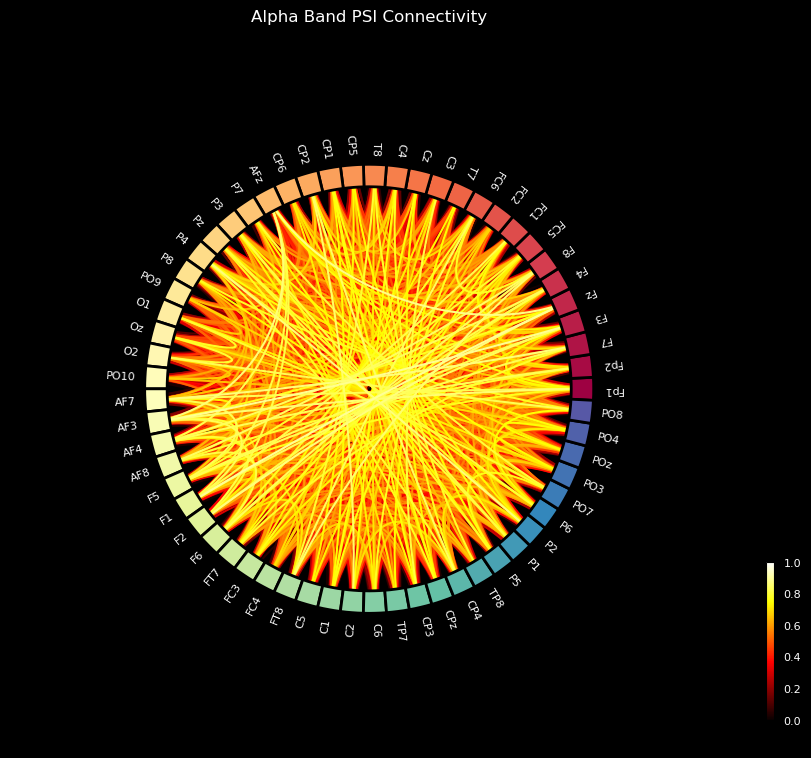

(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'Alpha Band PSI Connectivity'}>)

In [14]:
plot_connectivity_circle(psi_all['alpha'], raw.ch_names, title='Alpha Band PSI Connectivity', vmin=0, vmax=1)

In [11]:
n_channels = phase.shape[0]
psi_matrix = np.zeros((n_channels, n_channels))

# Compute n:m phase-phase coupling for each channel pair
for i in range(n_channels):
    for j in range(n_channels):
        phase_diff = phase[j] - phase[i]
        # Compute PSI for the current m
        psi = np.abs(np.mean(np.exp(1j * phase_diff)))
        psi_matrix[i, j] = psi

    psi_matrix = np.array(psi_matrix)

print(psi_matrix)

KeyboardInterrupt: 

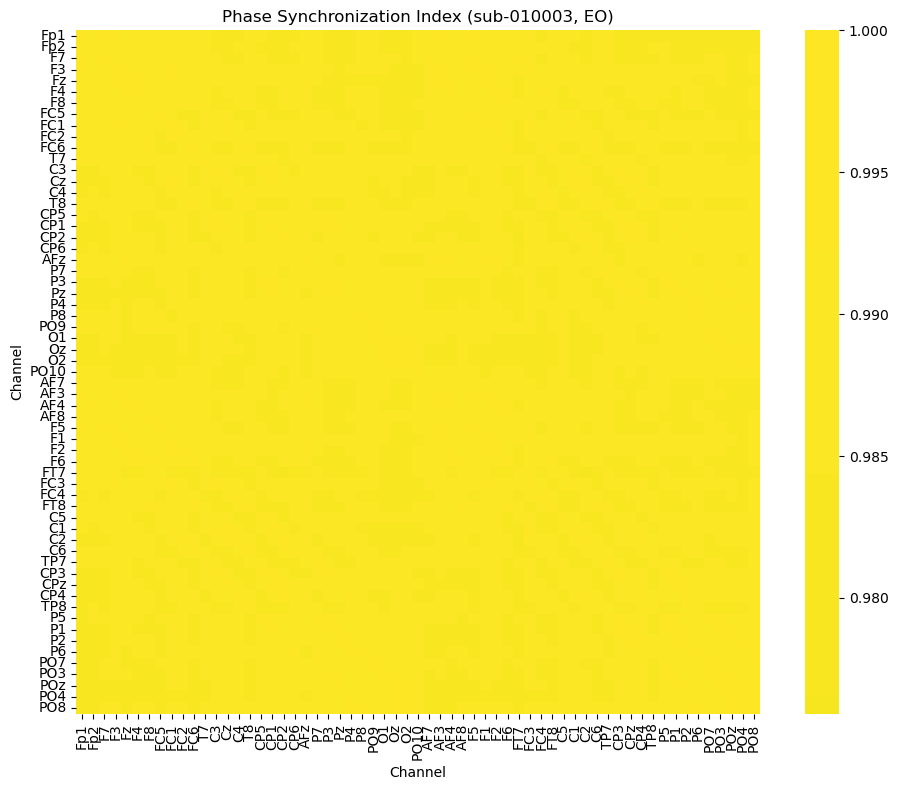

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(psi_matrix, xticklabels=epochs.ch_names, yticklabels=epochs.ch_names,
        cmap='viridis', center=0, annot=False, fmt=".2f", square=True)
plt.title(f'Phase Synchronization Index ({id}, {condition})')
plt.xlabel('Channel')
plt.ylabel('Channel')
plt.tight_layout()


In [ ]:
def compute_phase(x):
    """ヒルベルト変換で瞬時位相を計算"""
    from scipy.signal import hilbert
    return np.angle(hilbert(x))

def PSI(x, y, N=100):
    """Phase Synchronization Index"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta_phase = phase_x - phase_y
    psi_vals = []
    for i in range(0, len(delta_phase)-N):
        psi_vals.append(np.abs(np.mean(np.exp(1j*delta_phase[i:i+N]))))
    return np.array(psi_vals)

def Imaginary_Coh(x, y):
    """Imaginary Coherence"""
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    csd = X * np.conj(Y)
    imag_coh = np.imag(np.mean(csd)) / np.sqrt(np.mean(np.abs(X)**2) * np.mean(np.abs(Y)**2))
    return np.abs(imag_coh)

def PLI(x, y):
    """Phase Lag Index"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta_phase = phase_x - phase_y
    return np.abs(np.mean(np.sign(np.sin(delta_phase))))

def wPLI(x, y):
    """Weighted Phase Lag Index"""
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    imag_part = np.imag(X * np.conj(Y))
    return np.abs(np.sum(np.abs(imag_part) * np.sign(imag_part))) / np.sum(np.abs(imag_part))

def dPSI(x, y, fs=250):
    """Differential PSI（位相遅れの変化量を評価）"""
    phase_x = compute_phase(x)
    phase_y = compute_phase(y)
    delta = np.unwrap(phase_x - phase_y)
    d_delta = np.diff(delta)
    return np.mean(np.abs(d_delta))

In [ ]:
PSI(x, y, N=100)

In [15]:
from scipy.signal import welch
import numpy as np

def compute_psd_multichannel(raw, nperseg=None):
    """
    raw : MNE Raw オブジェクト
    nperseg : Welch 法の窓長（サンプル数）
    """
    data = raw.get_data()  # shape = (n_channels, n_samples)
    fs = raw.info["sfreq"]
    n_channels = data.shape[0]

    # デフォルトの窓長 = 2秒
    if nperseg is None:
        nperseg = int(fs * 2)

    # PSDを保存するリスト
    psd_list = []
    freqs = None

    for ch in range(n_channels):
        f, Pxx = welch(data[ch], fs=fs, nperseg=nperseg)
        if freqs is None:
            freqs = f
        psd_list.append(Pxx)

    psd_array = np.array(psd_list)  # shape = (n_channels, n_freqs)

    return freqs, psd_array


In [16]:
import matplotlib.pyplot as plt

def plot_psd_all_channels(freqs, psd_array, fmax=60):
    plt.figure(figsize=(10, 6))
    for ch in range(psd_array.shape[0]):
        plt.plot(freqs, psd_array[ch], alpha=0.3)

    plt.xlim(0, fmax)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title("PSD of All Channels (Welch)")
    plt.grid(True)
    plt.show()


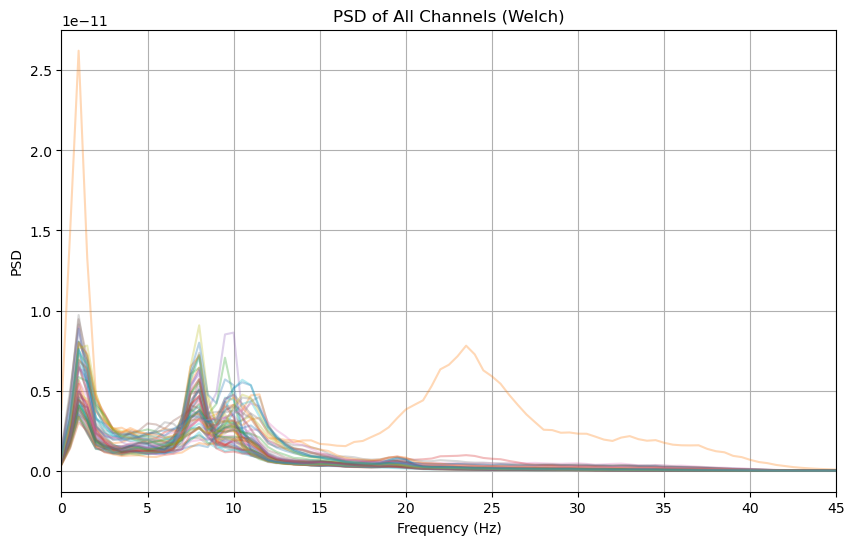

In [18]:
freqs, psd_array = compute_psd_multichannel(raw)
plot_psd_all_channels(freqs, psd_array, fmax=45)

In [19]:
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}


In [20]:
from scipy.signal import welch
import numpy as np

def compute_band_power(raw, bands, nperseg=None):
    """
    raw: MNE Raw object
    bands: dict → 各バンドの周波数帯
    """

    data = raw.get_data()   # (n_channels, n_samples)
    fs = raw.info['sfreq']

    if nperseg is None:
        nperseg = int(fs * 2)  # 2秒窓

    # PSD 計算（チャンネル×周波数）
    freqs, psd = welch(
        data,
        fs=fs,
        nperseg=nperseg,
        axis=1
    )

    band_power = {}

    for band_name, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_power[band_name] = np.mean(psd[:, idx], axis=1)  # (n_channels)

    return freqs, psd, band_power


In [21]:
import mne
import matplotlib.pyplot as plt

def plot_bandpower_topomap(raw, band_power, band_name):
    """
    raw: MNE Raw object
    band_power: band_power[band_name] の 1次元配列（n_channels）
    """

    mne.viz.plot_topomap(
        band_power,
        raw.info,
        cmap="viridis",
        contours=0,
        sphere=0.1
    )

    plt.title(f"{band_name} band power")
    plt.show()


In [22]:
def plot_all_band_topomaps(raw, band_power):
    for band in band_power.keys():
        plot_bandpower_topomap(raw, band_power[band], band)


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bandpower_bar(band_power):
    """
    band_power: compute_band_power() で得られる dict
                {band_name: (n_channels,) }
    """

    band_names = list(band_power.keys())
    mean_values = [np.mean(band_power[b]) for b in band_names]

    plt.figure(figsize=(10, 5))
    plt.bar(band_names, mean_values)
    plt.ylabel("Mean Power (μV²/Hz)")
    plt.title("Band Power (Averaged across Channels)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


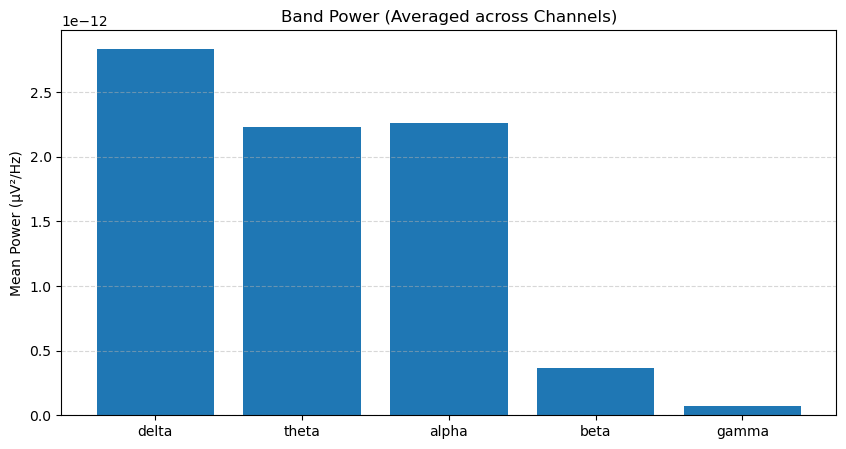

In [25]:
plot_bandpower_bar(band_power)

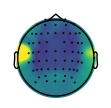

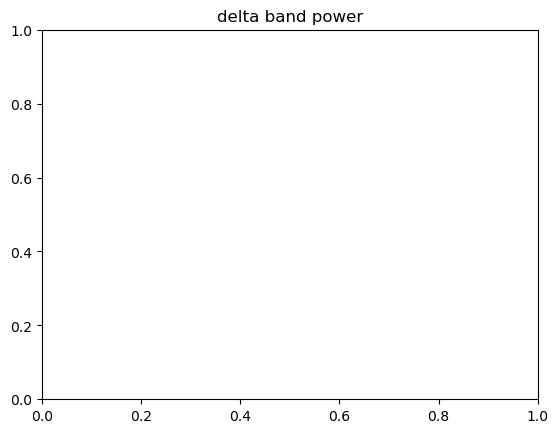

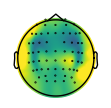

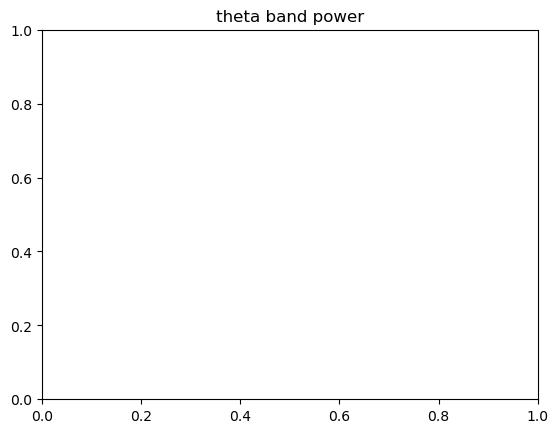

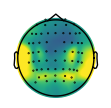

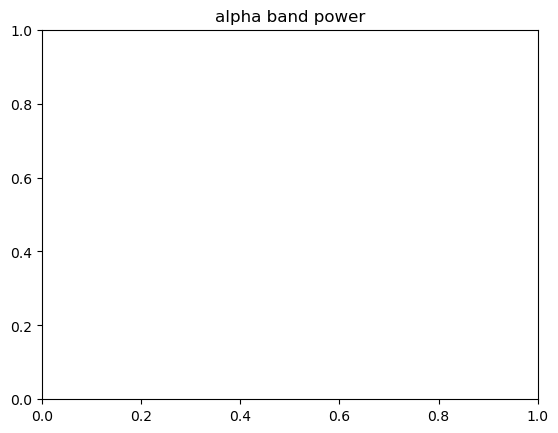

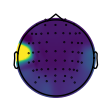

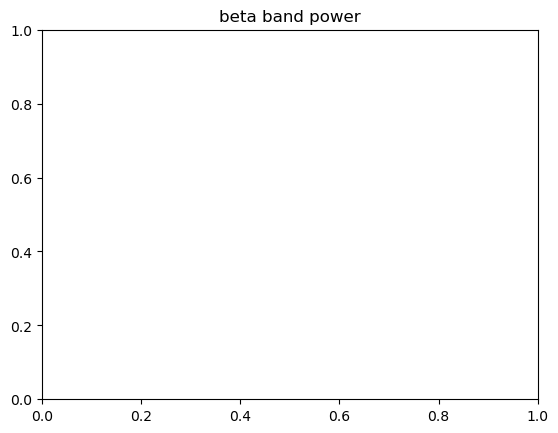

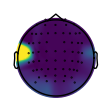

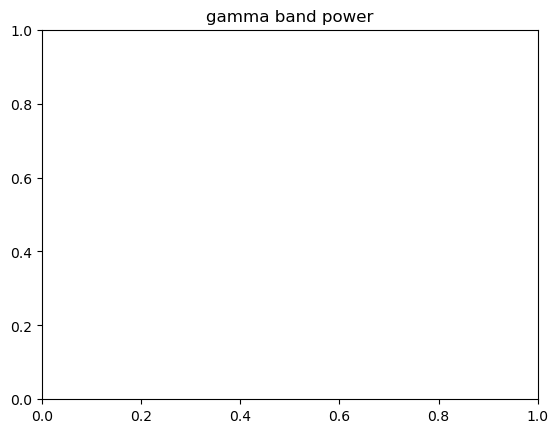

In [23]:
# Band power 計算
freqs, psd, band_power = compute_band_power(raw, bands)

# 各バンドのパワーをトポマップで表示
plot_all_band_topomaps(raw, band_power)


In [4]:
import mne
import numpy as np
import pandas as pd
import glob
import os
from scripts.eeg.connectivity import get_subject_ids, get_subject_metadata

# ▼ 周波数帯域の設定
FREQ_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45)
}

# ▼ 入出力
preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\preprocessed\\'
OUTPUT_CSV = "./bandpower_61ch_mean.csv"
metadata_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\metadata\\Participants_MPILMBB_LEMON.csv'

rows = []

# ▼ データ読み込みループ

subject_ids = get_subject_ids(preprocess_path)    

for id in subject_ids:
    for condition in ['EO', 'EC']:
        print(f"==={id}_{condition}===")
        # Define the paths to the raw EEG files
        path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

        # Load the raw data
        if not os.path.exists(path):
            print(f"Raw EEG file for condition {condition} does not exist: {path}")
            continue
        # Load the raw data   
        raw = mne.io.read_raw_fif(path, preload=True)
        if not raw.preload:
            raw.load_data()
        
        meta_info = get_subject_metadata(id, metadata_path)
        sex = meta_info["sex"]
        group = meta_info["group"]

        print("processing:", id)

        raw.filter(1, 45)

        # ▼ PSD（Power Spectral Density）
        psd, freqs = mne.time_frequency.psd_welch(raw, fmin=1, fmax=45, n_fft=1024)

        # ▼ 61ch 平均（PSD の shape: ch × freq）
        psd_mean_ch = psd.mean(axis=0)

        # ▼ バンドパワー計算
        band_vals = {}
        for band, (fmin, fmax) in FREQ_BANDS.items():
            idx = np.logical_and(freqs >= fmin, freqs < fmax)
            band_vals[band] = psd_mean_ch[idx].mean()

        # ▼ 1行分追加
        row = {
            "subject_id": id,
            "sex": sex,
            "group": group,
            "condition": condition
        }
        row.update(band_vals)
        rows.append(row)

        # ▼ 保存
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)

===sub-010002_EO===
processing: sub-010002


C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_49916\2108701695.py:49: RuntimeWarning: filter_length (8251) is longer than the signal (5001), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(1, 45)


AttributeError: No mne.time_frequency attribute psd_welch

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_FILE = "./bandpower_61ch_mean.csv"
df = pd.read_csv(CSV_FILE)

# 若年層 / 高齢層に分割
df_young = df[df["group"] == "young"]
df_old   = df[df["group"] == "old"]

bands = ["delta", "theta", "alpha", "beta", "gamma"]

mean_young = df_young[bands].mean()
mean_old   = df_old[bands].mean()

# ▼ 描画
x = np.arange(len(bands))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, mean_young, width, label="Young")
plt.bar(x + width/2, mean_old,   width, label="Old")

plt.xticks(x, bands)
plt.ylabel("Power (61ch mean)")
plt.title("Band Power Comparison: Young vs Old")
plt.legend()
plt.tight_layout()
plt.show()
